### Project 1
#### Nicholas Stirling
#### Department of Science, Math, and Technology, Bellevue University
#### DSC680-T301 Applied Data Science (2265-1)
#### Professor Amirfarrokh Iranitalab
#### April 5, 2026

In [1]:
import pandas as pd
import numpy as np
import re
import string

# Load dataset
df = pd.read_csv('Customer_support_data.csv')

# Inspect dataset
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [3]:
# Seperating out the structured variables that may later be used for profiling and business insights
structured_cols = [
    'category', 'Sub-category', 'Product_category',
    'channel_name', 'CSAT Score', 'Customer Remarks'
]

df = df[structured_cols].dropna(subset=['Customer Remarks']).reset_index(drop=True)

In [4]:
df.head()

,category,Sub-category,Product_category,channel_name,CSAT Score,Customer Remarks
0,Returns,Exchange / Replacement,NaN,Inbound,5,Very good
1,Returns,Missing,NaN,Inbound,5,Shopzilla app and it's all coustomer care serv...
2,Order Related,Delayed,LifeStyle,Inbound,1,Very bad
3,Order Related,Installation/demo,NaN,Inbound,3,Something
4,Order Related,Installation/demo,Electronics,Inbound,5,All good


Standardizing text data to reduce dimensionality and remove irrelevant tokens. This will allow us to have clean normalized text and structured variables retained to ready the dataset for NLP transformation.

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['cleaned_remarks'] = df['Customer Remarks'].apply(clean_text)

At this point we can transform the text into numerical format for clustering. We will be using TF-IDF to weight important words higher, reduce the impact of common, less informative words, and preserve interpretability. We will be using N-grams: (1,2) to capture phrases without substantially increasing complexity.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['cleaned_remarks'])

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (28742, 5000)


Now that each complaint is represented in a high dimensional vector we cna usa PCA to reduce the feature dimensionality to allow for visualization and noise reduction.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

Now that we have a 2d representation of the dataset we can move to clustering based on the text similiarity. This will be conducted using K-Means clustering. This will be efficient and should work well with the TF-IDF vectors. This will hopefully produce interpretable centroids. We will initially determine the optimal number of clusters using Inertia and Silhouette score.

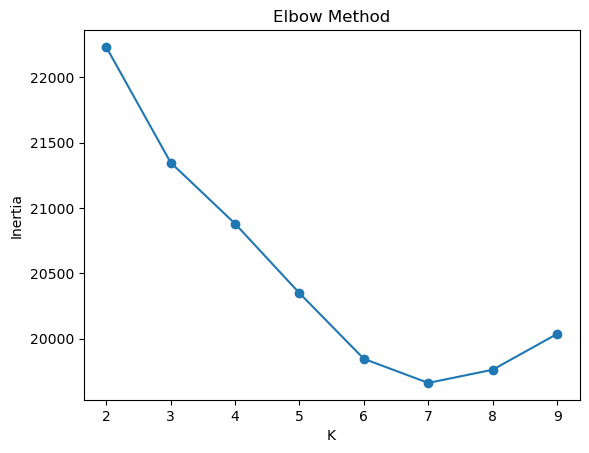

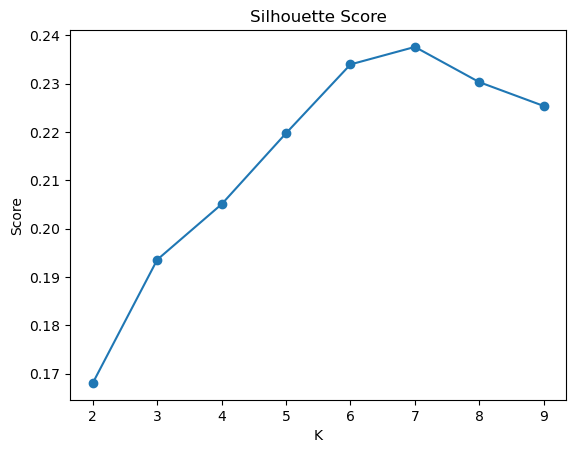

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot Elbow
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette
plt.figure()
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

Based on the output graphs the optimal k-value for clusters is 7. Both inertia (flattening) and silhouette score (maximum) occurs at 7 which will maximize cluster separability while maintaining meaningful structure. This should provide more granular and actionable themes in the clusters compared to lower K vlaues. However, clusters may need to be consolidated later if some of them are too similar from a business perspective.

In [10]:
optimal_k = 7

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

In [11]:
score = silhouette_score(X, df['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.2375623056059299


Initial silhouette score analysis shows a fairly weak clustering structure with may have quite a bit of overlap. This can be indicative of the high-dimensionality of the complaint and customer feedback data. While not sharply separated there will hopefully be enough for interpretable business insights.

In [12]:
terms = tfidf.get_feature_names_out()
centroids = kmeans.cluster_centers_

def get_top_terms(cluster_idx, n=10):
    indices = centroids[cluster_idx].argsort()[::-1][:n]
    return [terms[i] for i in indices]

for i in range(optimal_k):
    print(f"\nCluster {i} Top Terms:")
    print(get_top_terms(i))


Cluster 0 Top Terms:
['good', 'service', 'shopzilla', 'good costomer', 'good better', 'good boy', 'good care', 'good communicate', 'good communication', 'good condition']

Cluster 1 Top Terms:
['nice', 'feedback', 'mam', 'understand', 'satisfied', 'sir', 'experience', 'nice nice', 'baat', 'super']

Cluster 2 Top Terms:
['thank', 'thank shopzilla', 'thank sir', 'sir', 'shopzilla', 'mam', 'okay', 'supportive', 'ok', 'executive']

Cluster 3 Top Terms:
['excellent', 'excellent service', 'service', 'excellent customer', 'excellent performance', 'performance', 'excellent work', 'customer service', 'customer', 'excellent support']

Cluster 4 Top Terms:
['good', 'customer', 'service', 'happy', 'shopzilla', 'support', 'problem', 'product', 'ok', 'issue']

Cluster 5 Top Terms:
['thanks', 'thanks shopzilla', 'shopzilla', 'thanks support', 'support', 'nice', 'care', 'ji', 'overall', 'information']

Cluster 6 Top Terms:
['bad', 'bad service', 'service', 'bad experience', 'experience', 'shopzilla',

Results show segmentation was based on sentiment/tone of customer feedback. The outcomes appear to align as with group 0 being generally positive experiences, group 1 moderate satisfaction, group 2 appreciative, group 3 exceptional service experience, group 4 Mixed results, group 5 low positive feedback, group 6 negative experience. Of these, group 4 and 6 are likely to hold high business insight into potentially operational opportunities.  
This also shows the clustering results were driven by sentiment dimensions rather than operational issue categories. While this doesn't allow direct root-cause analysis, it can be used to monitor customer experience quality and identify high-risk dissatifaciton clusters.

In [14]:
df['complaint_flag'] = 1
cluster_summary = df.groupby('cluster').agg({
    'CSAT Score': 'mean',
    'complaint_flag': 'count'
}).rename(columns={'complaint_flag': 'volume'})

print(cluster_summary)

         CSAT Score  volume
cluster                    
0          4.765211    4421
1          4.807975     953
2          4.806833     761
3          4.913580     405
4          3.885169   20970
5          4.743758     761
6          1.473461     471


In [17]:
pd.crosstab(df['cluster'], df['channel_name'])

channel_name,Email,Inbound,Outcall
cluster,,,
0,154,3540,727
1,33,766,154
2,33,571,157
3,9,312,84
4,738,16563,3669
5,17,634,110
6,42,349,80


The cluster summary confirms the initial analysis and indication that CLuster 4 and 6 are the lowest performing in terms of CSAT scores, while Cluster 4 has the large majority of the volume across clusters. This can be visualized showing the distribution of clusters by volume vs Average CSAT.

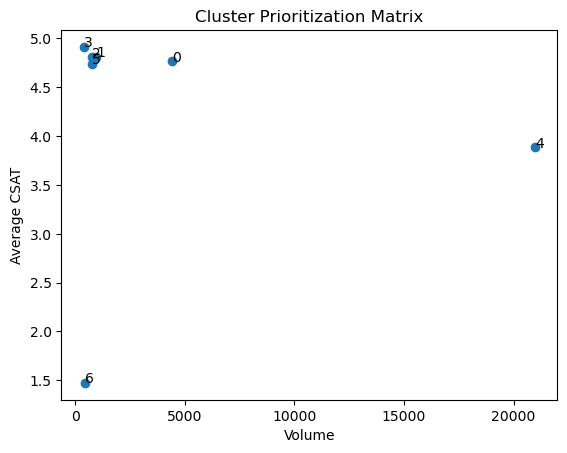

In [18]:
plt.figure()
plt.scatter(cluster_summary['volume'], cluster_summary['CSAT Score'])
for i, txt in enumerate(cluster_summary.index):
    plt.annotate(txt, (cluster_summary['volume'][i], cluster_summary['CSAT Score'][i]))

plt.xlabel("Volume")
plt.ylabel("Average CSAT")
plt.title("Cluster Prioritization Matrix")
plt.show()

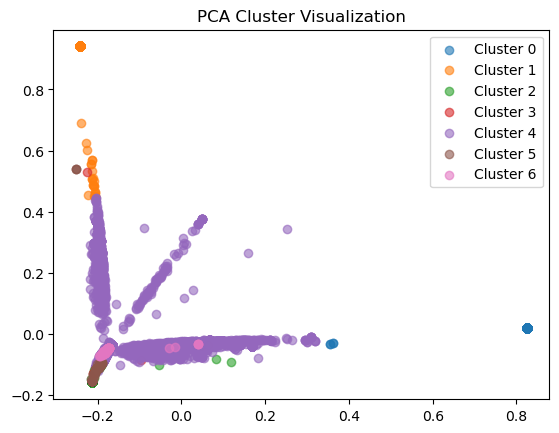

In [19]:
# PCA Scatter Plot
plt.figure()
for c in range(optimal_k):
    plt.scatter(
        X_reduced[df['cluster'] == c, 0],
        X_reduced[df['cluster'] == c, 1],
        label=f'Cluster {c}',
        alpha=0.6
    )

plt.legend()
plt.title("PCA Cluster Visualization")
plt.show()

While some clear separation of the clusters can be seen in the PCA visualization it is not distinct enough across clusters to help communicate to an audience. Creation of bar charts showing the variance between clusters in both volume and CSAT will create a clear emphasis on prioritization rationale.

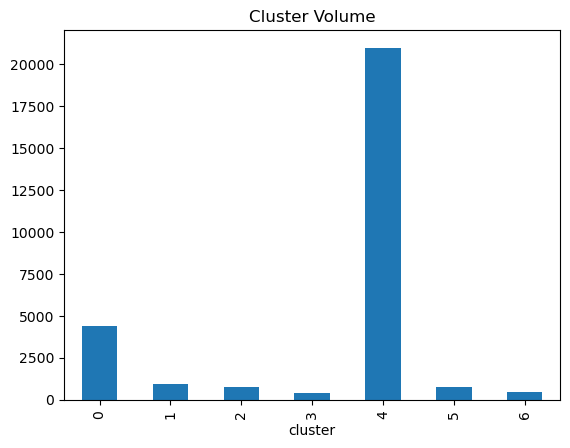

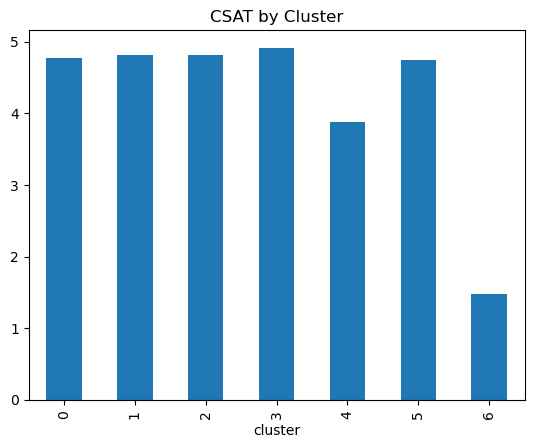

In [20]:
# Cluster Size
cluster_summary['volume'].plot(kind='bar', title='Cluster Volume')
plt.show()

# CSAT by Cluster
cluster_summary['CSAT Score'].plot(kind='bar', title='CSAT by Cluster')
plt.show()